In [1]:
import pandas as pd
import numpy as np

import pickle
import sys
sys.path.append('../')

from gemininn.chain_model import *
from gemininn import models, data, reports


from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score



import torch

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
AUX_COLS = ["velocity","mass","deceleration_average"]
AUX_COLS_EXT = AUX_COLS  + [f'PCA_{i}' for i in range(10)]

NUM_LABELS = 4
NUM_CLASSES = 12


In [4]:
with open('pipeline.pkl', 'rb') as f:
    chains = pickle.load(f)

In [5]:
chains

Pipeline(steps=[('preprocessor',
                 FeatureUnion(transformer_list=[('tab',
                                                 Pipeline(steps=[('selector',
                                                                  DataFrameSelector(columns=['velocity',
                                                                                             'mass',
                                                                                             'deceleration_average'])),
                                                                 ('imputer',
                                                                  KNNImputer()),
                                                                 ('scaler',
                                                                  StandardScaler())])),
                                                ('sensor',
                                                 Pipeline(steps=[('selector',
                                                                  SensorSelector()),
                                                                 ('scaler',
                                                                  SensorScaler()),
                                                                 ('features',
                                                                  SensorFeatureTransformer())]))]...
                                                            importance_type=None,
                                                            interaction_constraints=None,
                                                            learning_rate=None,
                                                            max_bin=None,
                                                            max_cat_threshold=None,
                                                            max_cat_to_onehot=None,
                                                            max_delta_step=None,
                                                            max_depth=None,
                                                            max_leaves=None,
                                                            min_child_weight=None,
                                                            missing=nan,
                                                            monotone_constraints=None,
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...),
                               thresholds=array([0.3 , 0.3 , 0.25, 0.2 ])))])

In [6]:
extended_cnn_model = models.ConfigurableTwoBranchCNN(
     num_aux_feats=13,
     num_labels=4,
     conv_channels=[32, 64, 128],
     pool_sizes=[(2,2), (2,2), (2,1)],
        sensor_shape=(128, 6),

     in_channels=1)

In [7]:
path = "../cnn-2d/ExtendedCNNStandartData_silent_raven_20250613_174931/ExtendedCNNStandartData_silent_raven_20250613_174931.pt"
a = torch.load(path, map_location="cpu")
extended_cnn_model.load_state_dict(a)

<All keys matched successfully>

In [8]:
with open("../data/data_2.0/X_ext_train.pickle", "rb") as f:
    X_train = pickle.load(f)
with open("../data/data_2.0/y_train.pickle", "rb") as f:
    y_train = pickle.load(f)
    
with open("../data/data_2.0/X_ext_test.pickle", "rb") as f:
    X_test = pickle.load(f)
with open("../data/data_2.0/y_test.pickle", "rb") as f:
    y_test = pickle.load(f)
    


In [9]:
def laberer(label):
    return np.array(label_to_tuple(label), dtype=np.int64)

In [10]:
y_train_v = np.vstack(y_train.apply(laberer).values)
y_test_v = np.vstack(y_test.apply(laberer).values)

In [11]:
with open("../data/train.pickle", "rb") as f:
    train = pickle.load(f)
with open("../data/test.pickle", "rb") as f:
    test = pickle.load(f)

In [12]:
y_score_ch_train = chains.predict_proba(train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [13]:
y_pred_ch_train = chains.predict_proba(train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [14]:
y_score_ch_test = chains.predict_proba(test)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [15]:
y_pred_ch_test = chains.predict(test)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [16]:
loaders_label = data.build_all_loaders(X_train, y_train_v,
                                       X_train, y_train_v,
                                       X_test, y_test_v,
                                       sensor_key='sensor_data', 
                                       pers_key='pers_image',
                                       aux_cols=AUX_COLS, 
                                       ext_aux_cols=AUX_COLS_EXT)

In [17]:
y_true_test, y_pred_nn_test, y_score_nn_test = reports.predict_multilabel(extended_cnn_model, loaders_label['test_ext'])

In [18]:
y_true_train, y_pred_nn_train, y_score_nn_train = reports.predict_multilabel(extended_cnn_model, loaders_label['train_ext'])


=== Ensemble: cal_avg ===
=== Multilabel Classification Report ===
              precision    recall  f1-score   support

           0       0.13      0.66      0.22       103
           1       0.19      0.78      0.30        96
           2       0.59      0.25      0.35       104
           3       0.19      0.83      0.31       105

   micro avg       0.18      0.63      0.28       408
   macro avg       0.27      0.63      0.29       408
weighted avg       0.28      0.63      0.29       408
 samples avg       0.14      0.26      0.18       408



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


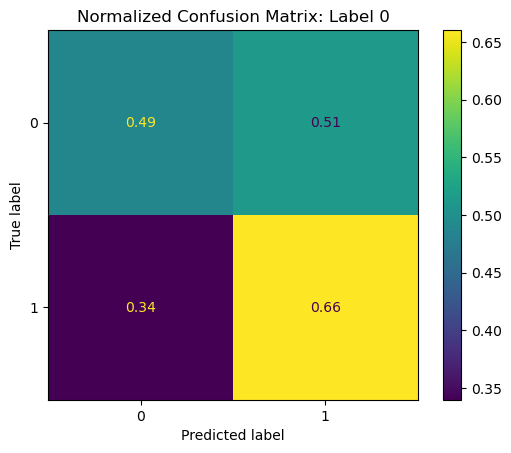

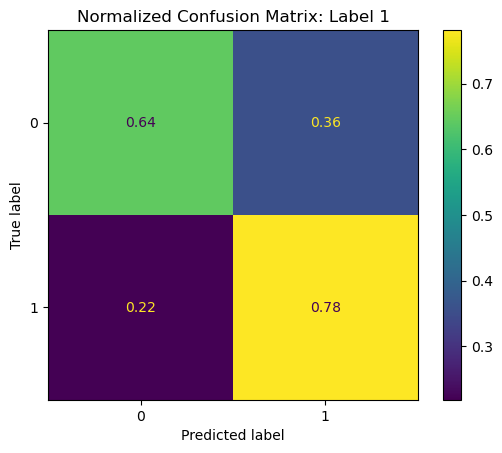

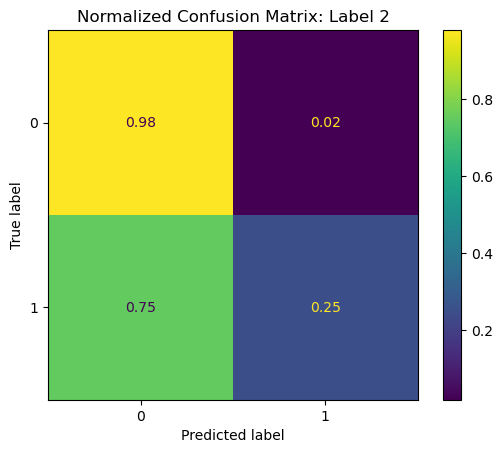

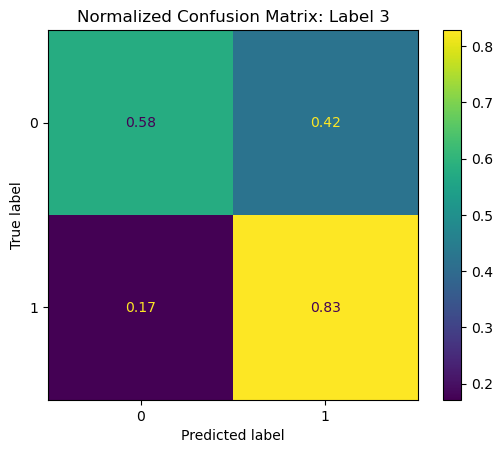

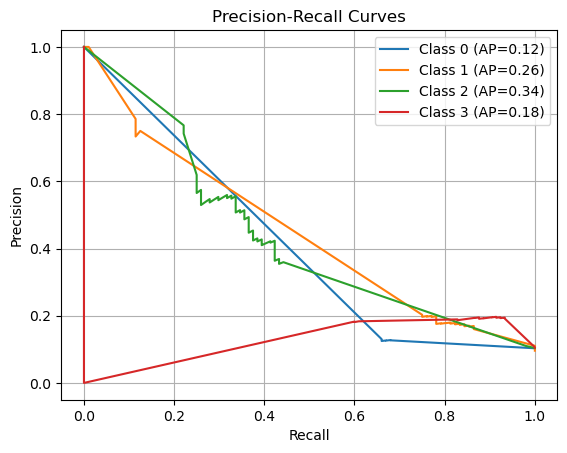

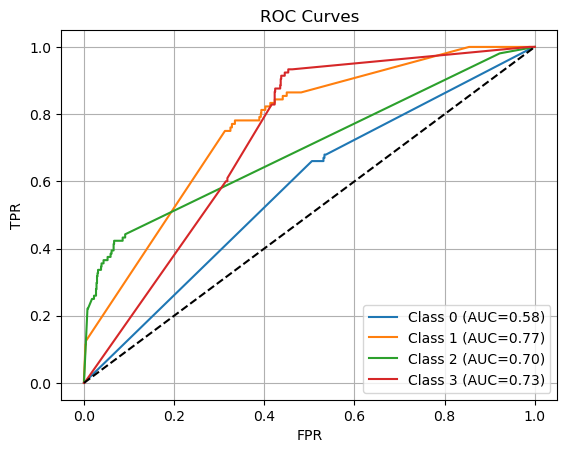

              precision    recall  f1-score   support

    negative       0.85      0.30      0.44       593
    positive       0.48      0.92      0.63       408

    accuracy                           0.55      1001
   macro avg       0.66      0.61      0.54      1001
weighted avg       0.70      0.55      0.52      1001



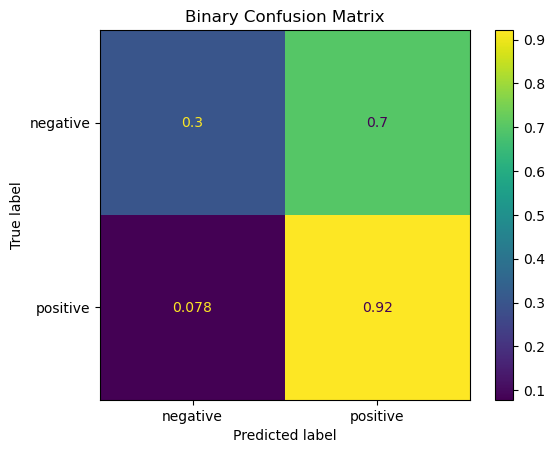

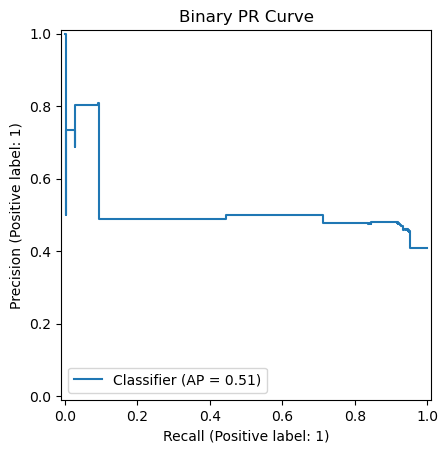

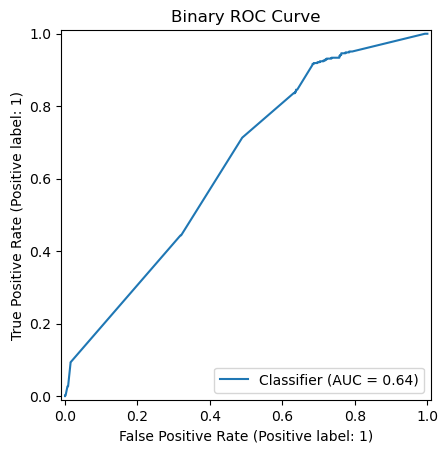


=== Ensemble: label_w ===
=== Multilabel Classification Report ===
              precision    recall  f1-score   support

           0       0.12      0.51      0.20       103
           1       0.20      0.78      0.32        96
           2       0.42      0.38      0.40       104
           3       0.19      0.88      0.32       105

   micro avg       0.19      0.63      0.29       408
   macro avg       0.23      0.64      0.31       408
weighted avg       0.24      0.63      0.31       408
 samples avg       0.15      0.26      0.18       408



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


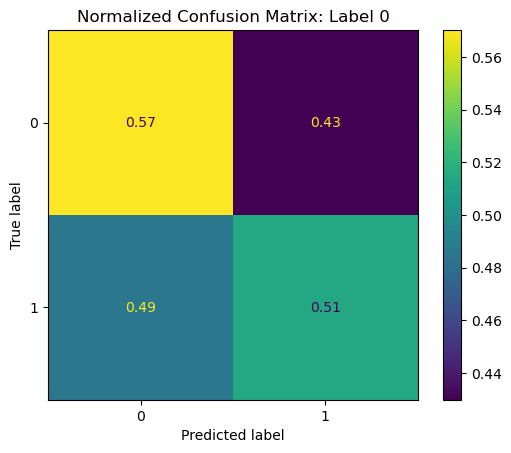

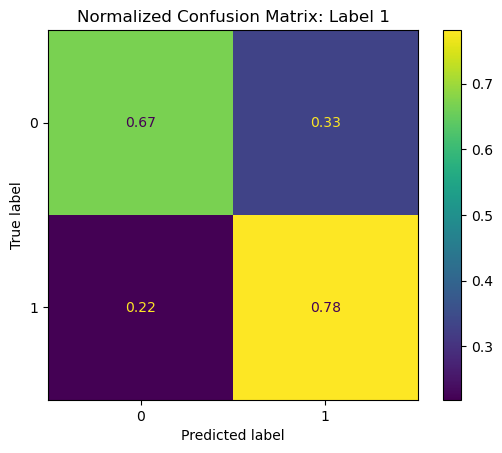

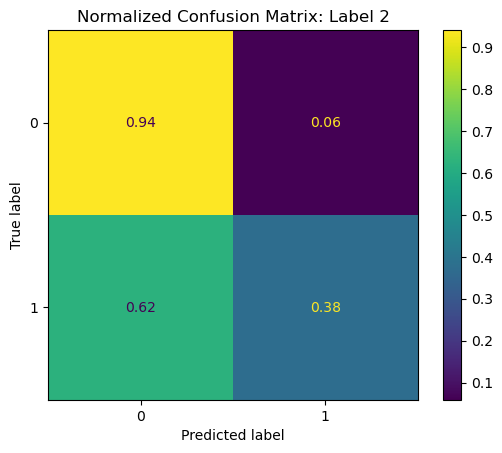

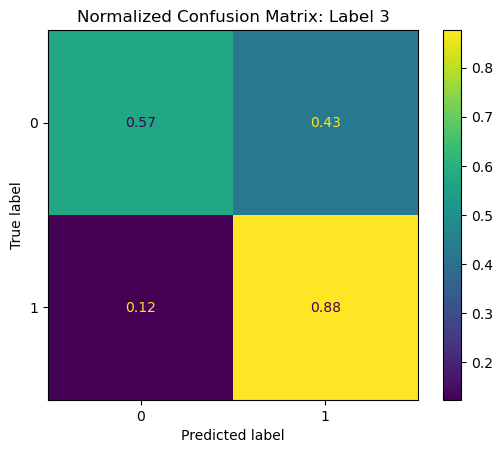

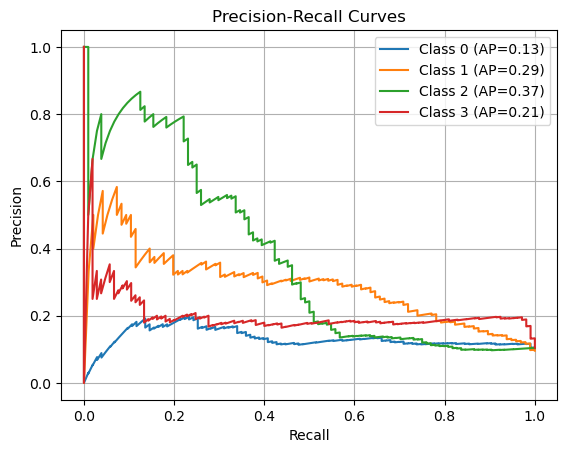

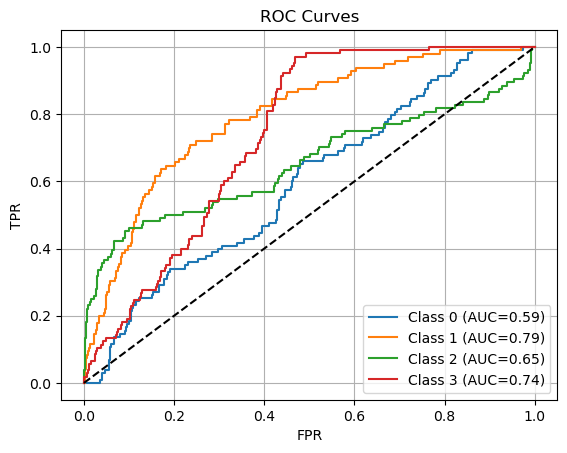

              precision    recall  f1-score   support

    negative       0.84      0.33      0.47       593
    positive       0.48      0.91      0.63       408

    accuracy                           0.56      1001
   macro avg       0.66      0.62      0.55      1001
weighted avg       0.69      0.56      0.54      1001



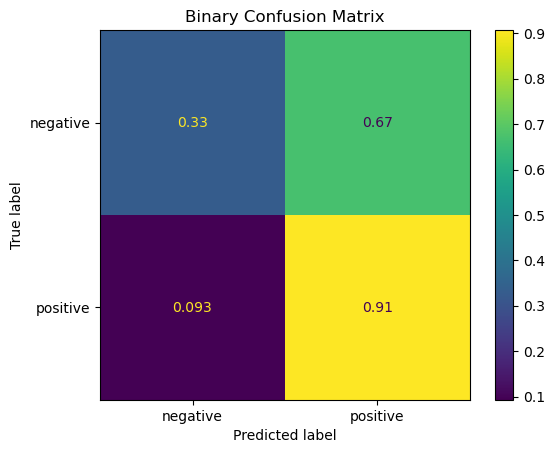

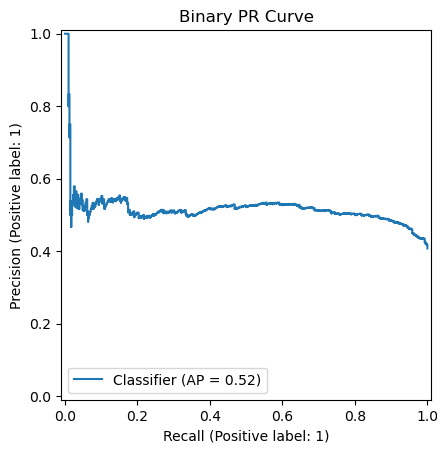

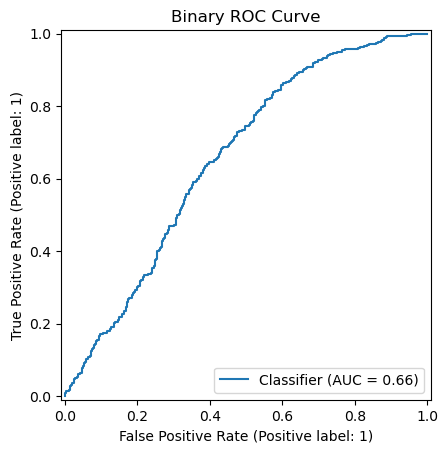


=== Ensemble: gated ===
=== Multilabel Classification Report ===
              precision    recall  f1-score   support

           0       0.22      0.51      0.31       103
           1       0.31      0.59      0.40        96
           2       0.50      0.33      0.40       104
           3       0.19      0.30      0.23       105

   micro avg       0.27      0.43      0.33       408
   macro avg       0.30      0.43      0.34       408
weighted avg       0.30      0.43      0.33       408
 samples avg       0.15      0.17      0.16       408



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


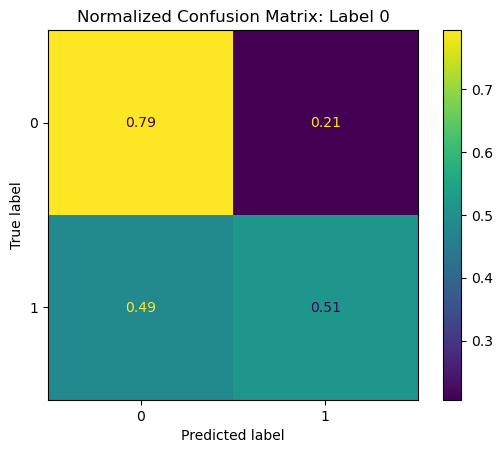

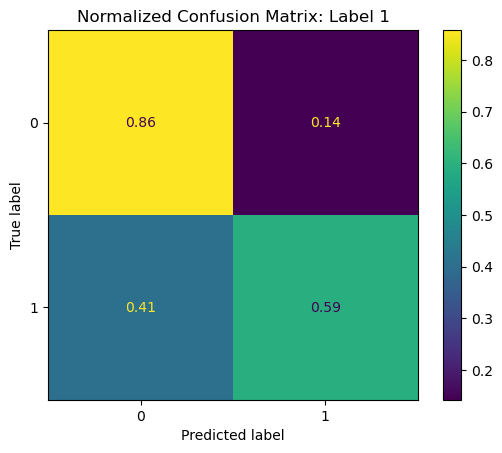

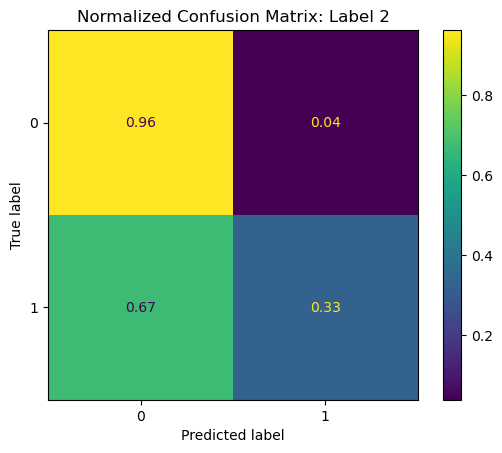

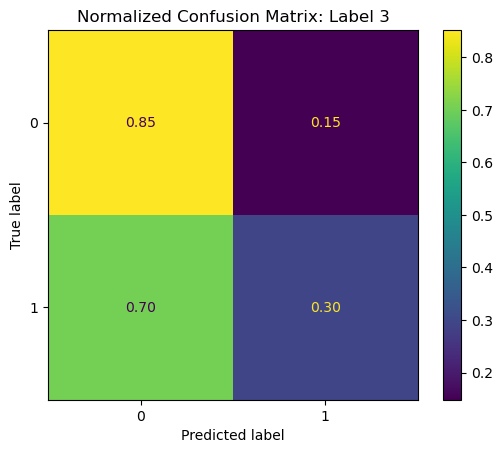

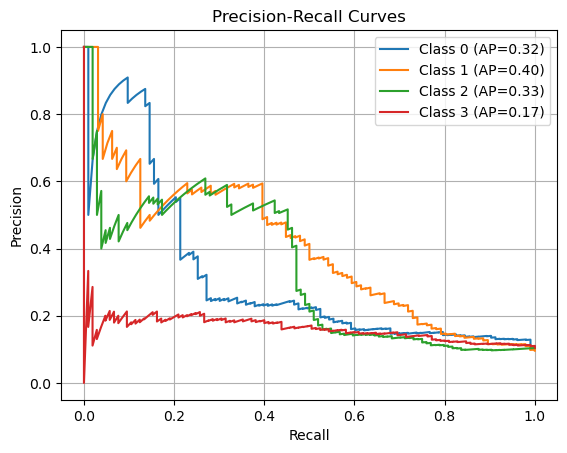

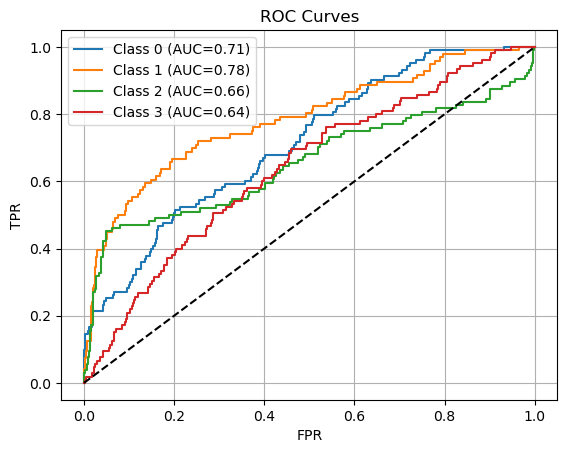

              precision    recall  f1-score   support

    negative       0.68      0.56      0.61       593
    positive       0.49      0.61      0.54       408

    accuracy                           0.58      1001
   macro avg       0.58      0.59      0.58      1001
weighted avg       0.60      0.58      0.58      1001



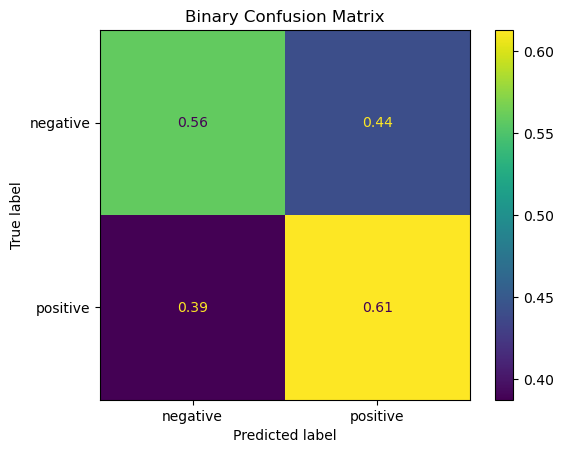

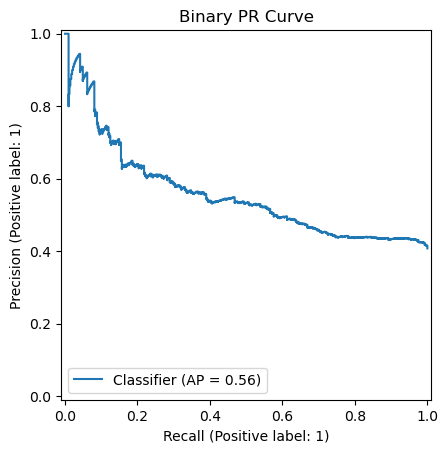

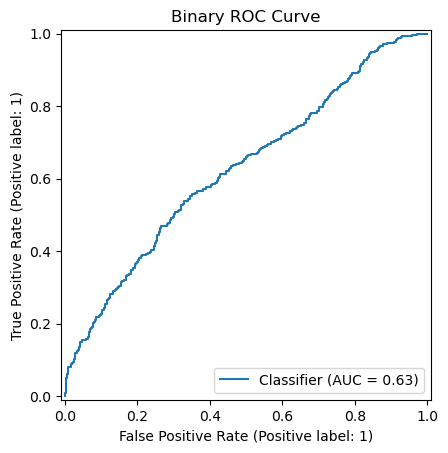


=== Ensemble: rank ===
=== Multilabel Classification Report ===
              precision    recall  f1-score   support

           0       0.13      0.66      0.22       103
           1       0.17      0.94      0.29        96
           2       0.17      0.71      0.27       104
           3       0.15      0.70      0.24       105

   micro avg       0.15      0.75      0.26       408
   macro avg       0.16      0.75      0.26       408
weighted avg       0.15      0.75      0.26       408
 samples avg       0.16      0.31      0.20       408



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


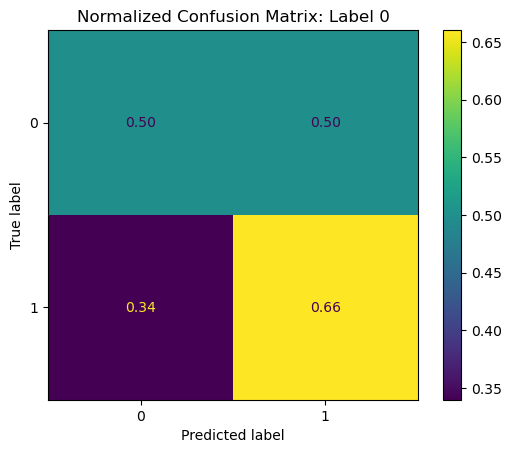

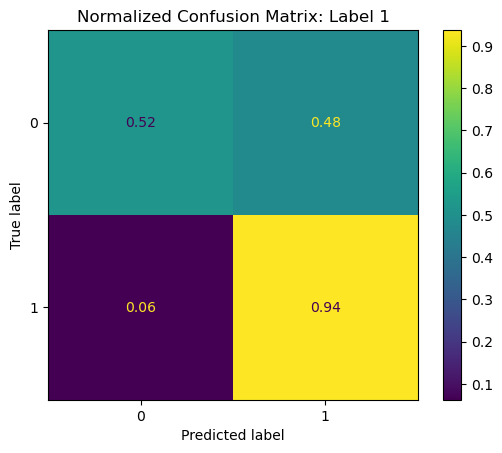

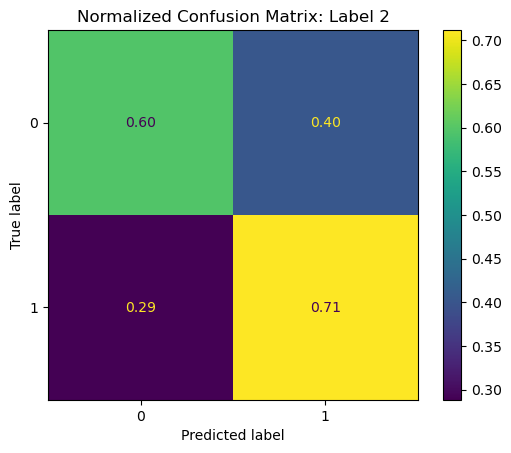

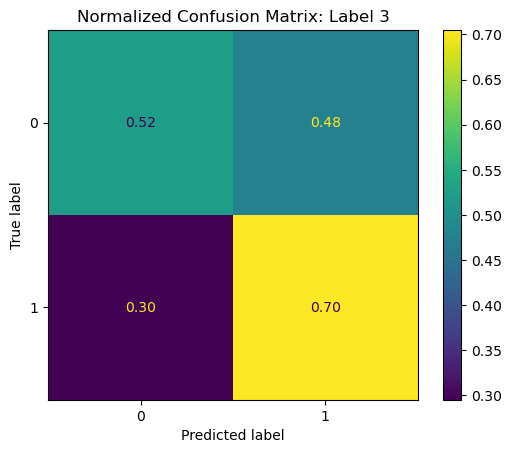

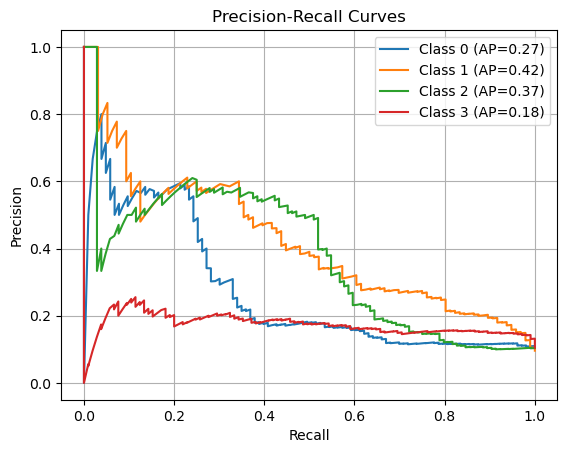

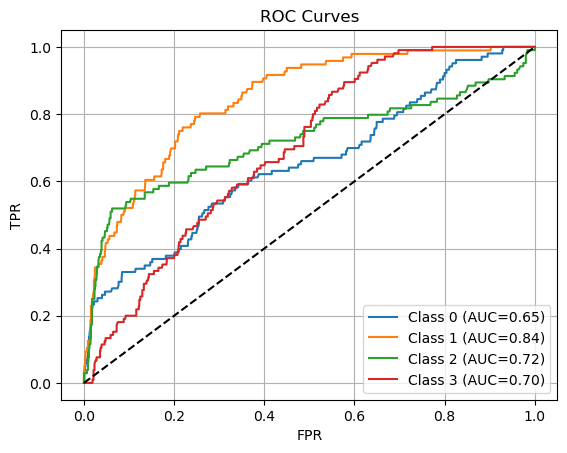

              precision    recall  f1-score   support

    negative       0.78      0.12      0.21       593
    positive       0.43      0.95      0.59       408

    accuracy                           0.46      1001
   macro avg       0.60      0.54      0.40      1001
weighted avg       0.64      0.46      0.36      1001



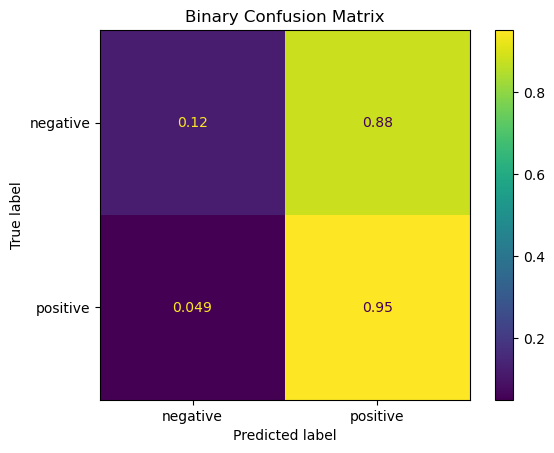

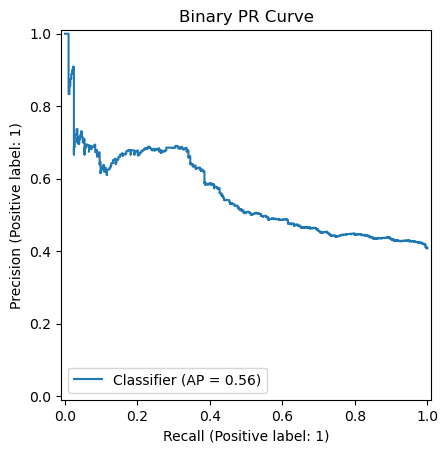

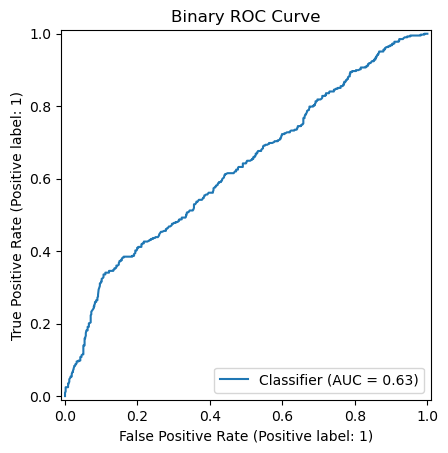


=== Ensemble: ds ===
=== Multilabel Classification Report ===
              precision    recall  f1-score   support

           0       0.15      0.52      0.24       103
           1       0.25      0.67      0.36        96
           2       0.44      0.50      0.47       104
           3       0.17      0.50      0.25       105

   micro avg       0.21      0.54      0.31       408
   macro avg       0.25      0.55      0.33       408
weighted avg       0.25      0.54      0.33       408
 samples avg       0.16      0.22      0.18       408



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


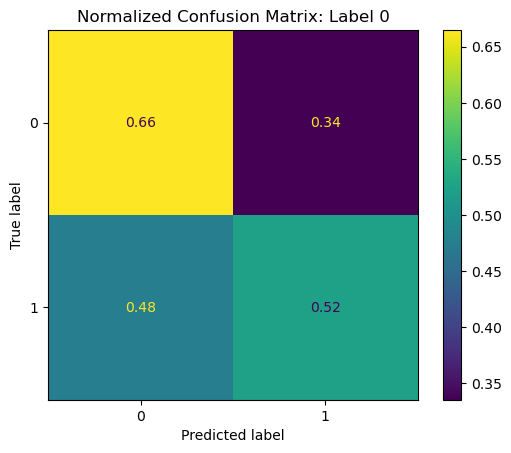

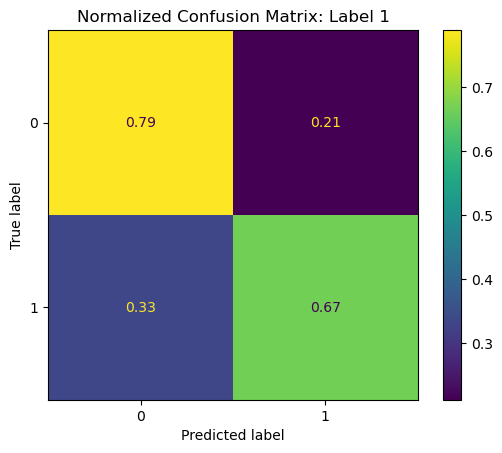

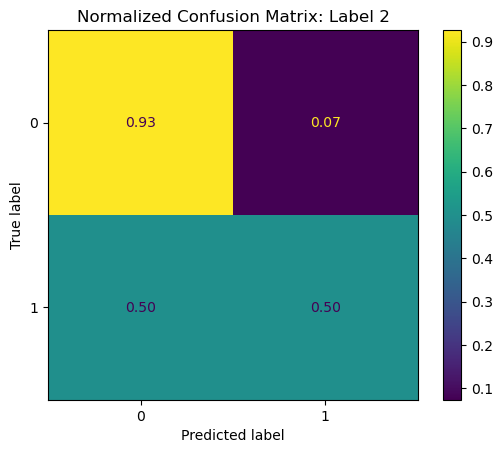

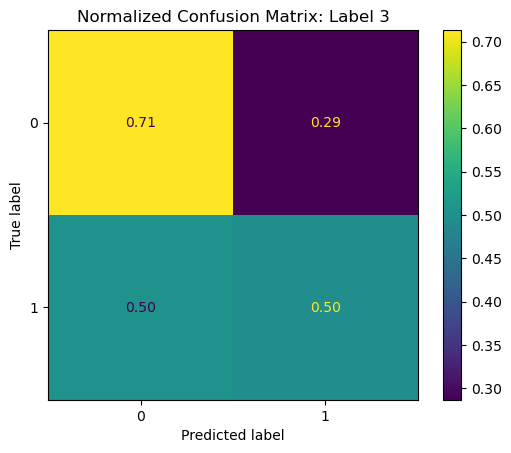

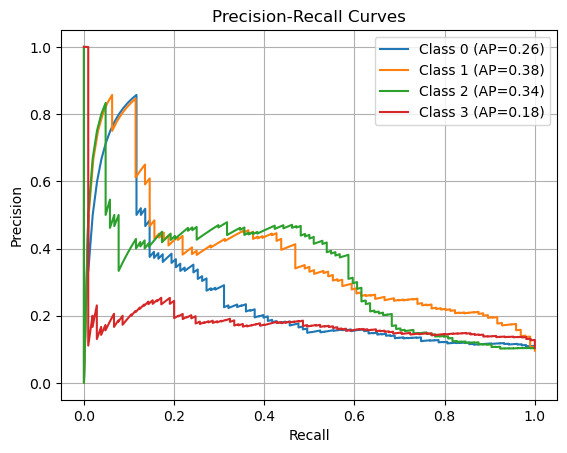

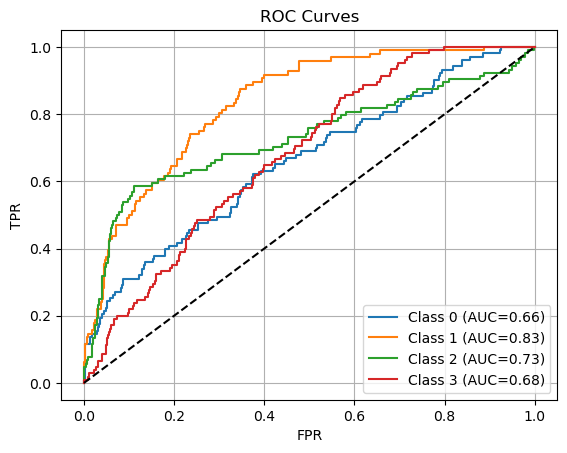

              precision    recall  f1-score   support

    negative       0.66      0.35      0.46       593
    positive       0.44      0.73      0.55       408

    accuracy                           0.51      1001
   macro avg       0.55      0.54      0.50      1001
weighted avg       0.57      0.51      0.50      1001



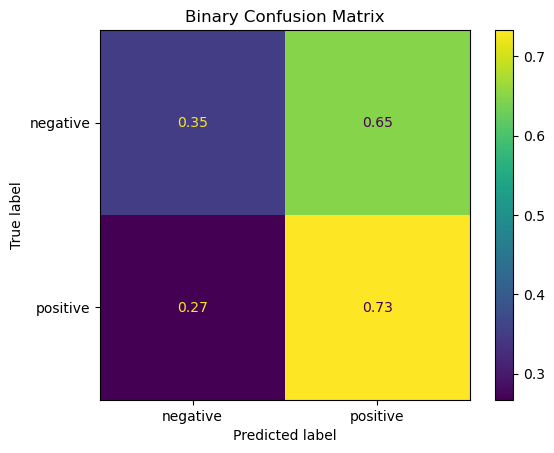

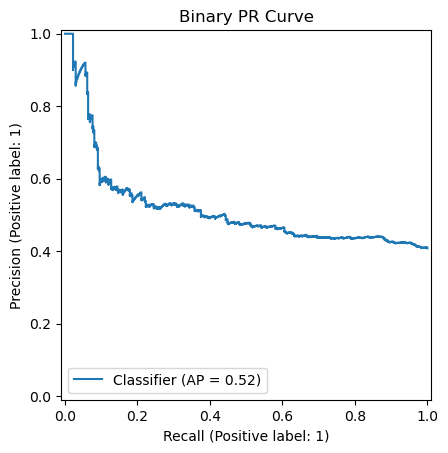

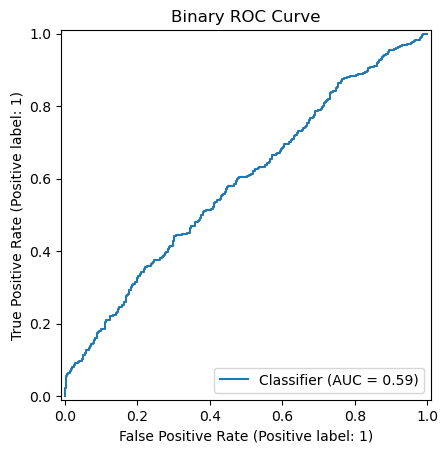


=== Ensemble: stack ===
=== Multilabel Classification Report ===
              precision    recall  f1-score   support

           0       0.13      0.57      0.21       103
           1       0.20      0.78      0.31        96
           2       0.39      0.42      0.40       104
           3       0.19      0.88      0.32       105

   micro avg       0.19      0.66      0.29       408
   macro avg       0.23      0.66      0.31       408
weighted avg       0.23      0.66      0.31       408
 samples avg       0.15      0.27      0.19       408



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


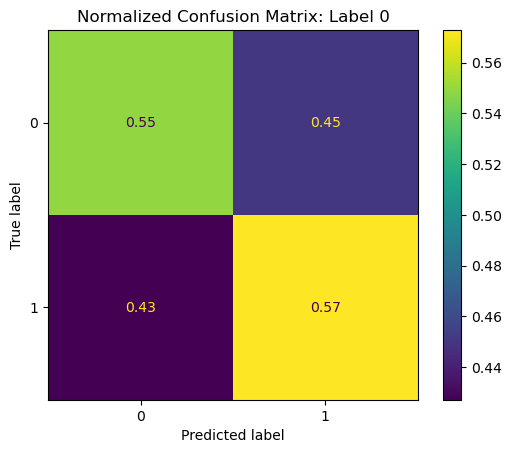

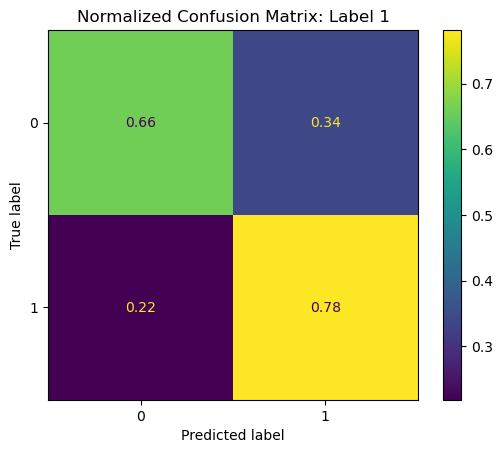

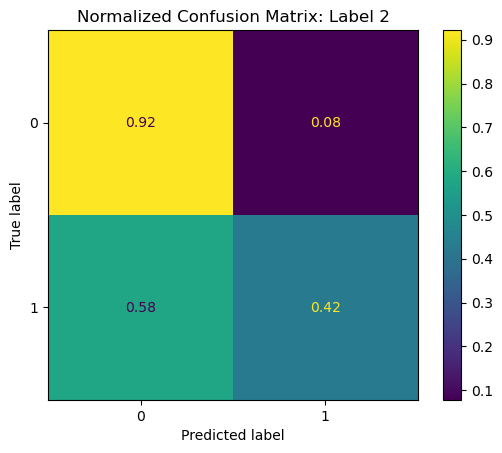

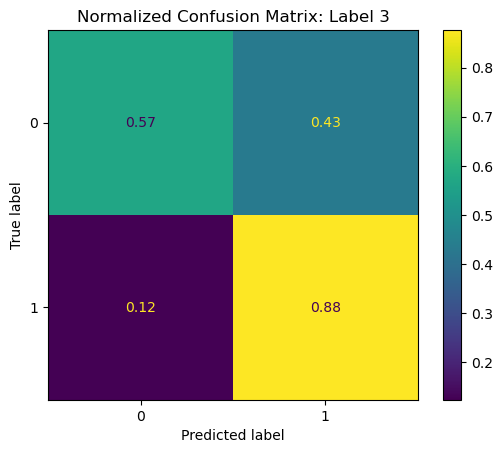

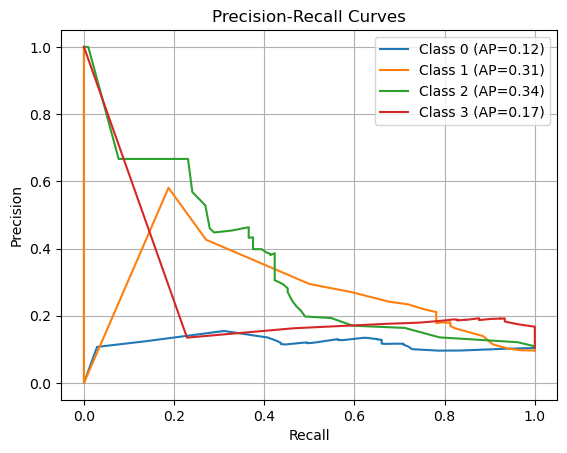

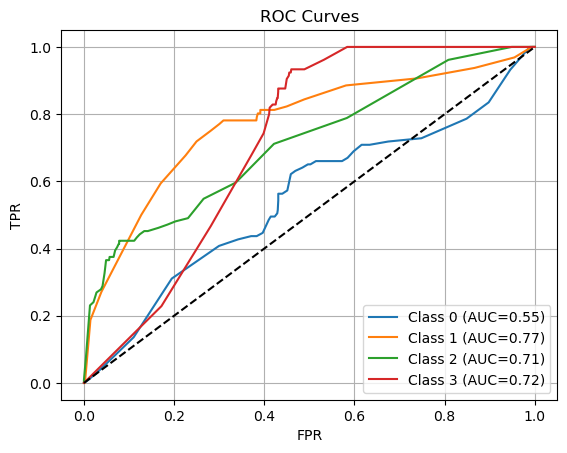

              precision    recall  f1-score   support

    negative       0.85      0.31      0.45       593
    positive       0.48      0.92      0.63       408

    accuracy                           0.56      1001
   macro avg       0.66      0.61      0.54      1001
weighted avg       0.70      0.56      0.52      1001



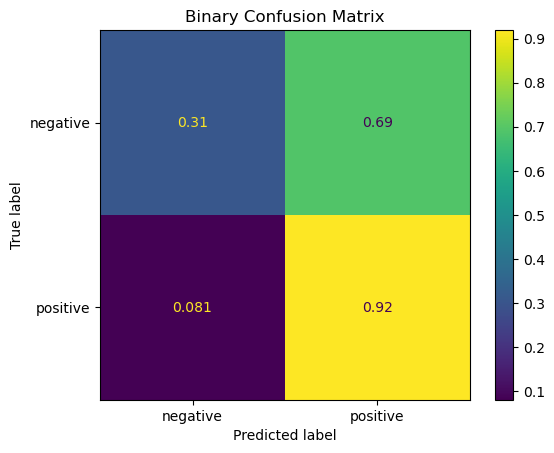

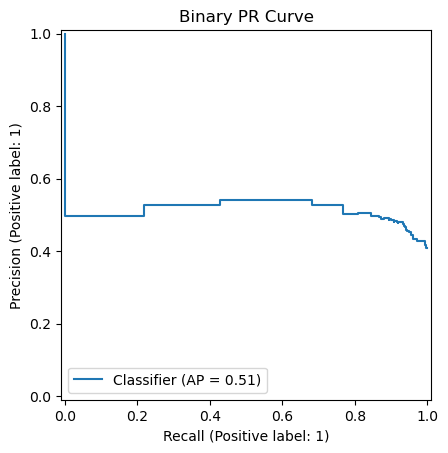

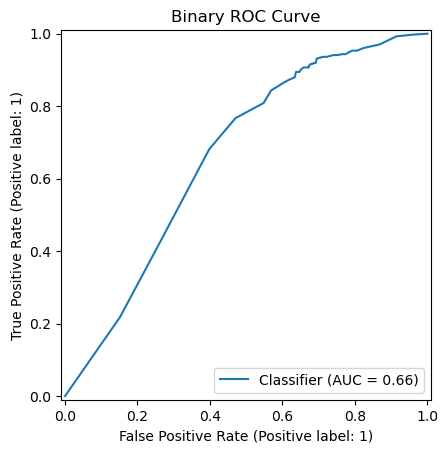

In [20]:
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# -------------------------------------------------------------------

n_labels = y_true_train.shape[1]


(ch_tr, ch_cal,
 nn_tr, nn_cal,
 y_tr,    y_cal) = train_test_split(
    y_score_ch_train, y_score_nn_train, y_true_train,
    test_size=0.2, random_state=0
)

calibrators_ch = [
    IsotonicRegression(out_of_bounds='clip').fit(ch_cal[:, i], y_cal[:, i])
    for i in range(n_labels)
]
calibrators_nn = [
    IsotonicRegression(out_of_bounds='clip').fit(nn_cal[:, i], y_cal[:, i])
    for i in range(n_labels)
]

def calibrate_all(scores, calibrators):
    out = np.zeros_like(scores)
    for i, iso in enumerate(calibrators):
        out[:, i] = iso.transform(scores[:, i])
    return out

y_ch_cal_train = calibrate_all(y_score_ch_train, calibrators_ch)
y_nn_cal_train = calibrate_all(y_score_nn_train, calibrators_nn)
y_score_cal_avg_train = (y_ch_cal_train + y_nn_cal_train) / 2

y_ch_cal_test = calibrate_all(y_score_ch_test, calibrators_ch)
y_nn_cal_test = calibrate_all(y_score_nn_test, calibrators_nn)
y_score_cal_avg_test = (y_ch_cal_test + y_nn_cal_test) / 2
y_pred_cal_avg_test  = (y_score_cal_avg_test >= 0.5).astype(int)


best_ws = np.zeros(n_labels)
for i in range(n_labels):
    best_f1, best_w = 0.0, 0.0
    for w in np.linspace(0, 1, 51):
        p = w*y_score_ch_train[:, i] + (1-w)*y_score_nn_train[:, i]
        f1 = f1_score(y_true_train[:, i], (p >= 0.5).astype(int))
        if f1 > best_f1:
            best_f1, best_w = f1, w
    best_ws[i] = best_w

y_score_lw_test = np.zeros_like(y_score_ch_test)
for i in range(n_labels):
    y_score_lw_test[:, i] = best_ws[i]*y_score_ch_test[:, i] + (1-best_ws[i])*y_score_nn_test[:, i]
y_pred_lw_test = (y_score_lw_test >= 0.5).astype(int)


X_meta_train = np.hstack([y_score_ch_train, y_score_nn_train])
X_meta_test  = np.hstack([y_score_ch_test,  y_score_nn_test])

gating_models = [
    LogisticRegression().fit(X_meta_train, y_true_train[:, i])
    for i in range(n_labels)
]

y_score_gated_test = np.zeros_like(y_score_ch_test)
for i, gm in enumerate(gating_models):
    w_i = gm.predict_proba(X_meta_test)[:, 1]
    y_score_gated_test[:, i] = w_i*y_score_ch_test[:, i] + (1-w_i)*y_score_nn_test[:, i]
y_pred_gated_test = (y_score_gated_test >= 0.5).astype(int)


def rank_avg(col1, col2):
    df = pd.DataFrame({'ch': col1, 'nn': col2})
    ranks = df.rank() / (len(df) + 1)
    return (ranks['ch'] + ranks['nn'])/2

y_score_rank_test = np.zeros_like(y_score_ch_test)
for i in range(n_labels):
    y_score_rank_test[:, i] = rank_avg(y_score_ch_test[:, i], y_score_nn_test[:, i])
y_pred_rank_test = (y_score_rank_test >= 0.5).astype(int)

def ds_combine(p1, p2):
    m1_1, m1_0 = p1, 1 - p1
    m2_1, m2_0 = p2, 1 - p2
    k = m1_1*m2_0 + m1_0*m2_1
    return (m1_1*m2_1) / (1 - k)

y_score_ds_test = np.zeros_like(y_score_ch_test)
for i in range(n_labels):
    y_score_ds_test[:, i] = ds_combine(y_score_ch_test[:, i], y_score_nn_test[:, i])
y_pred_ds_test = (y_score_ds_test >= 0.5).astype(int)


X_stack_train = np.hstack([
    y_score_ch_train, y_score_nn_train,
    y_pred_ch_train,  y_pred_nn_train
])
X_stack_test = np.hstack([
    y_score_ch_test,  y_score_nn_test,
    y_pred_ch_test,   y_pred_nn_test
])

stacker = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=50, random_state=0)
)
stacker.fit(X_stack_train, y_true_train)

y_score_stack_test = np.stack([
    clf.predict_proba(X_stack_test)[:, 1]
    for clf in stacker.estimators_
], axis=1)
y_pred_stack_test = (y_score_stack_test >= 0.5).astype(int)

# ------------------------------
# Evaluate all on TEST set
# ------------------------------
ensembles = {
    'cal_avg' : (y_pred_cal_avg_test,  y_score_cal_avg_test),
    'label_w' : (y_pred_lw_test,       y_score_lw_test),
    'gated'   : (y_pred_gated_test,    y_score_gated_test),
    'rank'    : (y_pred_rank_test,     y_score_rank_test),
    'ds'      : (y_pred_ds_test,       y_score_ds_test),
    'stack'   : (y_pred_stack_test,    y_score_stack_test),
}

for name, (y_p, y_s) in ensembles.items():
    print(f"\n=== Ensemble: {name} ===")
    reports.full_report_multilabel(y_true_test, y_p, y_s, plot=True)

=== Multilabel Classification Report ===
              precision    recall  f1-score   support

           0       0.16      0.62      0.25       103
           1       0.22      0.72      0.33        96
           2       0.24      0.57      0.33       104
           3       0.15      0.50      0.23       105

   micro avg       0.18      0.60      0.28       408
   macro avg       0.19      0.60      0.29       408
weighted avg       0.19      0.60      0.29       408
 samples avg       0.16      0.24      0.19       408



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


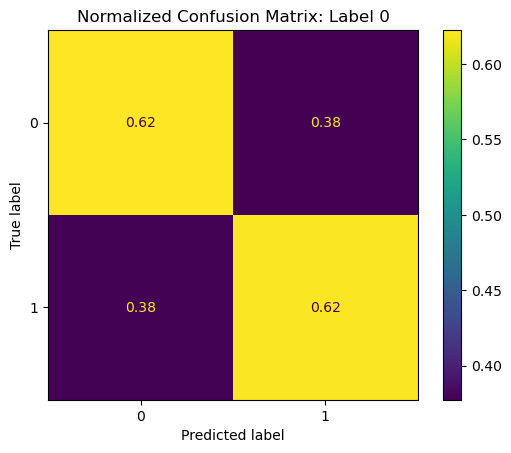

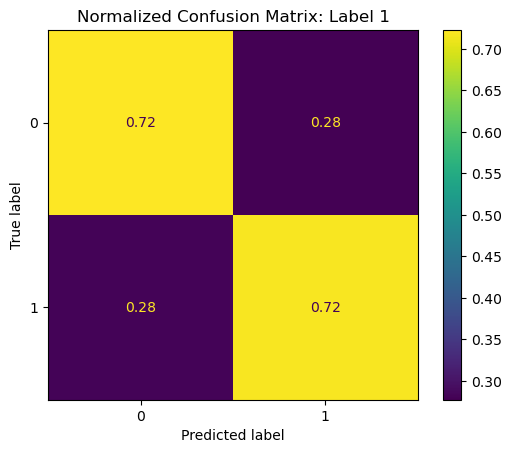

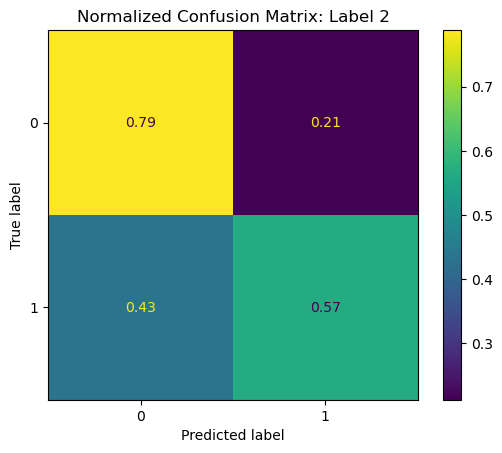

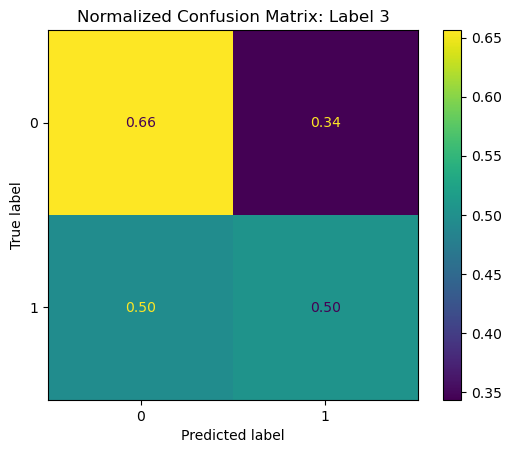

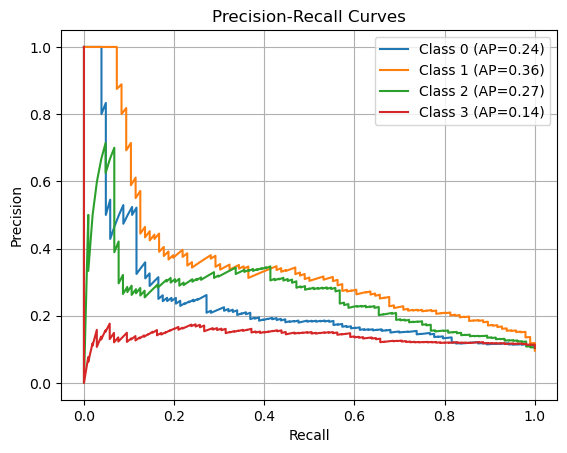

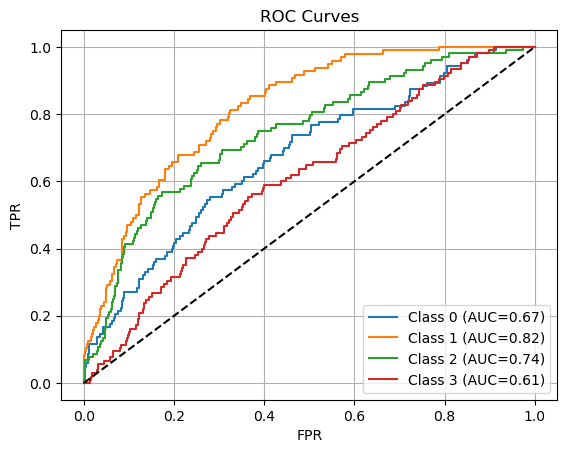

              precision    recall  f1-score   support

    negative       0.61      0.23      0.33       593
    positive       0.41      0.79      0.54       408

    accuracy                           0.46      1001
   macro avg       0.51      0.51      0.44      1001
weighted avg       0.53      0.46      0.42      1001



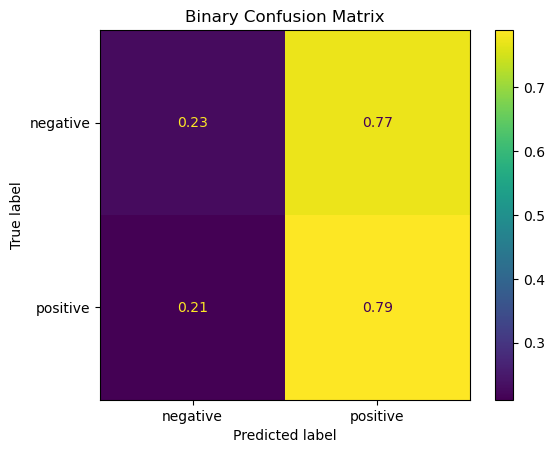

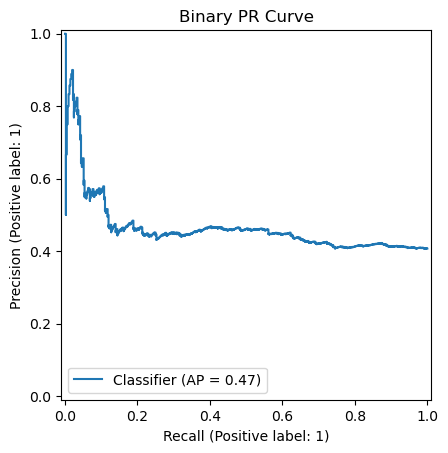

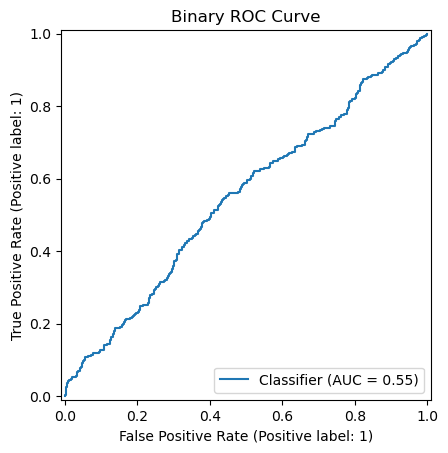

In [22]:
reports.full_report_multilabel(y_true_test, y_pred_ch_test, y_score_ch_test, plot=True)